<div style="background:linear-gradient(135deg,#0f2d5e 0%,#1a56a0 60%,#2d7dd2 100%);color:#fff;padding:36px 32px 28px;border-radius:12px;font-family:Inter,sans-serif">
<div style="font-size:11px;font-weight:600;letter-spacing:.15em;text-transform:uppercase;color:#93c5fd;margin-bottom:10px">Analytics Report · Salifort Motors · People Analytics</div>
<div style="font-family:'Playfair Display',Georgia,serif;font-size:32px;font-weight:700;line-height:1.15;margin-bottom:10px">Predicting Employee Attrition and What Drives It</div>
<div style="font-size:14px;color:#bfdbfe;max-width:640px">HR survey data for 11,991 unique employees · Logistic regression, decision tree, random forest, and XGBoost · PACE framework</div>
</div>

**Business question:** Which employees are likely to leave the company, and what factors drive that decision?
**Target variable:** `left` (1 = the employee left, whether they quit or were let go).
**Who uses the results:** Leadership and HR, to take proactive retention steps — not to penalize anyone.

### Ethical guardrails
* The model is a support tool. A high risk score is a prompt for a conversation, a workload review, or a career plan. Using predictions to fire people or cut bonuses is off the table — it would destroy trust and make future surveys dishonest.
* A false negative (missing someone who is about to leave) costs more than a false positive (an extra check-in with a manager). So **recall** is the priority, with acceptable **precision**. Models are selected on **F1**, with AUC as a secondary check.

<div style="font-size:11px;font-weight:600;letter-spacing:.12em;text-transform:uppercase;color:#1a56a0">Stage 1 · Plan</div>

## Load and Inspect the Data

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             classification_report)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

# ── Sergei Analytics brand style ─────────────────────────────────────────────
NAVY, BLUE, BLUE_2, SKY = '#0f2d5e', '#1a56a0', '#2d7dd2', '#93c5fd'
ORANGE, GREEN, TEXT, MUTED, BORDER = '#e8913a', '#10b981', '#1a1d2e', '#6b7280', '#e5e7eb'
STAYED, LEFT = BLUE, ORANGE                      # semantic colors used in every chart
plt.style.use('../sergei_analytics.mplstyle')
BRAND_CMAP = LinearSegmentedColormap.from_list('brand', [BLUE, '#ffffff', ORANGE])
PAL = {0: STAYED, 1: LEFT}
def finish(ax, title, subtitle=None):
    ax.set_title(title, loc='left', fontweight='semibold', color=TEXT)
    if subtitle: ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10, color=MUTED, va='bottom')

pd.set_option('display.float_format', '{:.3f}'.format)
RS = 42
df0 = pd.read_csv('../data/HR_capstone_dataset.csv')
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.380,0.530,2,157,3,0,1,0,sales,low
1,0.800,0.860,5,262,6,0,1,0,sales,medium
2,0.110,0.880,7,272,4,0,1,0,sales,medium
3,0.720,0.870,5,223,5,0,1,0,sales,low
4,0.370,0.520,2,159,3,0,1,0,sales,low


In [2]:
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


Standardize column names to snake_case, fix the `montly` typo, and give columns clearer names.

In [3]:
df0 = df0.rename(columns={'Work_accident':'work_accident','average_montly_hours':'average_monthly_hours',
                          'time_spend_company':'tenure','Department':'department'})
print('Missing values:', df0.isna().sum().sum())
print('Duplicate rows:', df0.duplicated().sum(), f'({df0.duplicated().mean():.1%} of rows)')

Missing values: 0
Duplicate rows: 3008 (20.1% of rows)


<div style="background:#eff6ff;border-left:3px solid #1a56a0;border-radius:0 8px 8px 0;padding:12px 16px;color:#1e3a6e;font-size:13px"><strong>Decision on duplicates.</strong> About 3,000 rows (20%) match on all 10 columns, including continuous ones (<code>satisfaction_level</code>, <code>last_evaluation</code>, <code>average_monthly_hours</code>). The odds of that happening naturally are negligible, so these are technical duplicates. We drop them; otherwise the same records would land in both training and test sets and inflate the metrics.</div>

In [4]:
df = df0.drop_duplicates(keep='first').reset_index(drop=True)
print(df.shape)
df.describe().T

(11991, 10)


,count,mean,std,min,25%,50%,75%,max
satisfaction_level,11991.000,0.630,0.241,0.090,0.480,0.660,0.820,1.000
last_evaluation,11991.000,0.717,0.168,0.360,0.570,0.720,0.860,1.000
number_project,11991.000,3.803,1.163,2.000,3.000,4.000,5.000,7.000
average_monthly_hours,11991.000,200.474,48.728,96.000,157.000,200.000,243.000,310.000
tenure,11991.000,3.365,1.330,2.000,3.000,3.000,4.000,10.000
work_accident,11991.000,0.154,0.361,0.000,0.000,0.000,0.000,1.000
left,11991.000,0.166,0.372,0.000,0.000,0.000,0.000,1.000
promotion_last_5years,11991.000,0.017,0.129,0.000,0.000,0.000,0.000,1.000


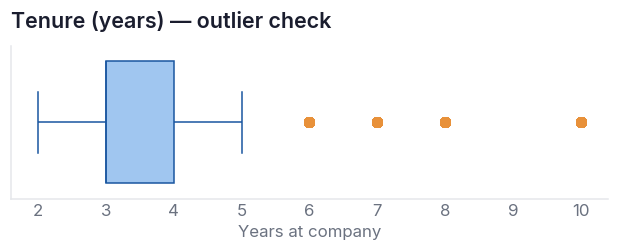

Upper IQR bound: 5.5; outlier rows: 824


In [5]:
fig, ax = plt.subplots(figsize=(7,1.8))
sns.boxplot(x=df['tenure'], ax=ax, color=SKY, linecolor=BLUE, flierprops=dict(markerfacecolor=ORANGE, markeredgecolor=ORANGE))
finish(ax, 'Tenure (years) — outlier check'); ax.set_xlabel('Years at company'); plt.show()
q1, q3 = df['tenure'].quantile([.25,.75]); upper = q3 + 1.5*(q3-q1)
print(f'Upper IQR bound: {upper}; outlier rows: {(df.tenure>upper).sum()}')

Tenure outliers (6+ years) are real employees, so we keep them for tree-based models and exclude them only for logistic regression, which is sensitive to outliers.

In [6]:
print(df['left'].value_counts(normalize=True))
print(f"Total: {df.left.sum():,} of {len(df):,} employees left")

left
0   0.834
1   0.166
Name: proportion, dtype: float64
Total: 1,991 of 11,991 employees left


Classes are moderately imbalanced (≈83/17). No resampling is needed — we use stratified splits and imbalance-robust metrics (F1, recall, AUC).

<div style="font-size:11px;font-weight:600;letter-spacing:.12em;text-transform:uppercase;color:#1a56a0">Stage 2 · Analyze</div>

## Exploratory Data Analysis

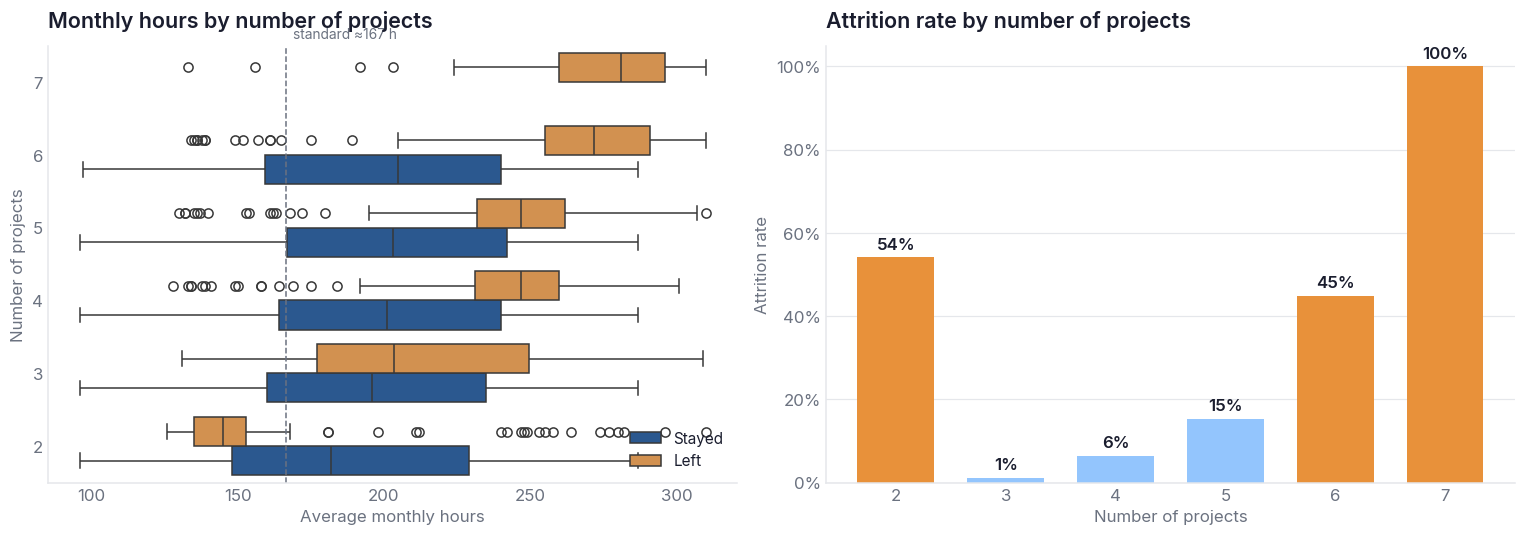

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='average_monthly_hours', y='number_project', hue='left', orient='h', ax=axes[0], palette=PAL)
axes[0].invert_yaxis(); axes[0].axvline(166.67, ls='--', c=MUTED, lw=1)
axes[0].text(169, 5.6, 'standard ≈167 h', fontsize=9, color=MUTED)
axes[0].set_xlabel('Average monthly hours'); axes[0].set_ylabel('Number of projects')
h,_ = axes[0].get_legend_handles_labels(); axes[0].legend(h, ['Stayed','Left'], loc='lower right')
finish(axes[0], 'Monthly hours by number of projects')
rate = df.groupby('number_project')['left'].mean()
axes[1].bar(rate.index, rate.values, color=[ORANGE if v>.3 else SKY for v in rate.values], width=.7)
for x,v in rate.items(): axes[1].text(x, v+.02, f'{v:.0%}', ha='center', fontweight='semibold', color=TEXT)
axes[1].set_xlabel('Number of projects'); axes[1].set_ylabel('Attrition rate'); axes[1].yaxis.set_major_formatter(lambda v,_: f'{v:.0%}')
finish(axes[1], 'Attrition rate by number of projects')
plt.tight_layout(); plt.savefig('../images/fig_projects.png'); plt.show()

<div style="background:#eff6ff;border-left:3px solid #1a56a0;border-radius:0 8px 8px 0;padding:12px 16px;color:#1e3a6e;font-size:13px"><strong>Takeaway:</strong> the relationship is U-shaped. People leave when they are <em>underloaded</em> (2 projects, 54% left) or <em>overloaded</em> (6 projects, 45%; <strong>7 projects, 100%</strong>). The sweet spot is 3–4 projects (1–6% attrition). A 40-hour week is ≈167 hours a month, yet the median employee works ~200 — overwork is systemic.</div>

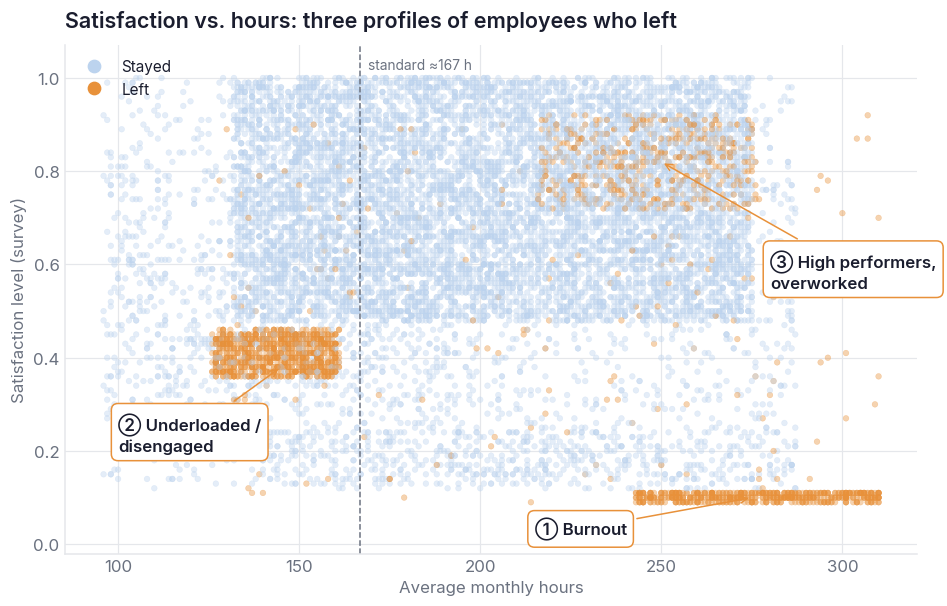

In [8]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df.sample(frac=1, random_state=RS), x='average_monthly_hours', y='satisfaction_level',
                hue='left', alpha=.4, s=14, palette={0:'#bcd3ee', 1:LEFT}, edgecolor=None, ax=ax)
ax.axvline(166.67, ls='--', c=MUTED, lw=1); ax.text(169, 1.02, 'standard ≈167 h', fontsize=9, color=MUTED)
box = dict(boxstyle='round,pad=.4', fc='white', ec=ORANGE)
kw = dict(fontsize=11, fontweight='semibold', color=TEXT, bbox=box, arrowprops=dict(arrowstyle='->', color=ORANGE))
ax.annotate('① Burnout', xy=(275,.10), xytext=(215,.02), **kw)
ax.annotate('② Underloaded /\ndisengaged', xy=(145,.38), xytext=(100,.20), **kw)
ax.annotate('③ High performers,\noverworked', xy=(250,.82), xytext=(280,.55), **kw)
ax.set_ylim(-.02, 1.07); ax.set_xlabel('Average monthly hours'); ax.set_ylabel('Satisfaction level (survey)')
from matplotlib.lines import Line2D
ax.legend([Line2D([],[],marker='o',ls='',color='#bcd3ee',ms=8), Line2D([],[],marker='o',ls='',color=LEFT,ms=8)], ['Stayed','Left'], loc='upper left')
ax.grid(axis='x')
finish(ax, 'Satisfaction vs. hours: three profiles of employees who left')
plt.savefig('../images/fig_clusters.png'); plt.show()

In [9]:
L = df[df.left==1]
seg = np.select([ (L.satisfaction_level<=.2)&(L.average_monthly_hours>215),
                  (L.satisfaction_level.between(.3,.5))&(L.average_monthly_hours<=165),
                  (L.satisfaction_level>.7)&(L.average_monthly_hours>215)],
                ['① Burnout','② Underloaded','③ High performers, overworked'], 'Other')
segs = L.assign(segment=seg).groupby('segment').agg(n=('left','size'), satisfaction=('satisfaction_level','mean'),
        evaluation=('last_evaluation','mean'), hours=('average_monthly_hours','mean'),
        projects=('number_project','mean'), tenure=('tenure','mean'))
segs['share_of_leavers'] = segs.n/len(L); segs.sort_values('n', ascending=False)

,n,satisfaction,evaluation,hours,projects,tenure,share_of_leavers
segment,,,,,,,
② Underloaded,845,0.408,0.515,143.586,2.049,3.020,0.424
① Burnout,508,0.103,0.868,276.443,6.195,4.106,0.255
"③ High performers, overworked",499,0.819,0.918,247.758,4.569,5.146,0.251
Other,139,0.512,0.740,209.043,4.129,3.755,0.070


**Three profiles explain ~93% of attrition:**
1. **Burnout** — 6–7 projects, 250–310 hours/month, satisfaction ≈0.1, high evaluation. The best people are pushed until they leave.
2. **Underloaded** — 2 projects, ~145 hours, satisfaction ≈0.4, low evaluation. Likely includes some involuntary terminations or people who had already checked out.
3. **High performers, overworked** — evaluation ≈0.9, satisfaction ≈0.8, 4–5 years of tenure. They like the work but leave anyway — most likely for growth or pay they are not getting here (see promotions below).

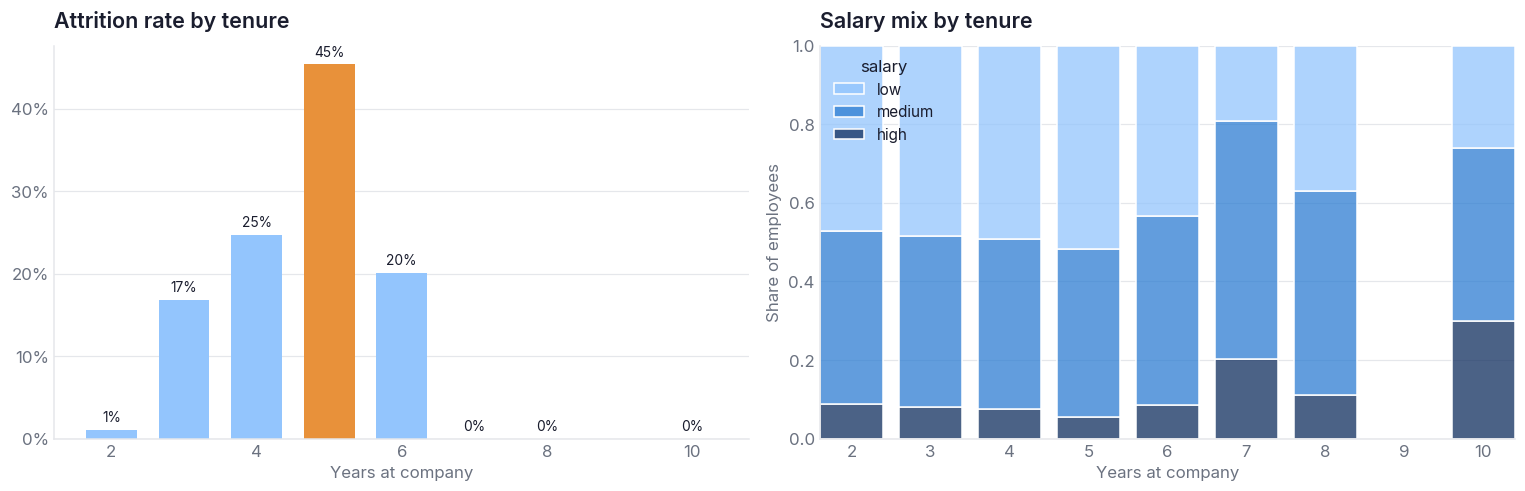

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,4.6))
t = df.groupby('tenure')['left'].mean()
axes[0].bar(t.index, t.values, color=[ORANGE if v>.3 else SKY for v in t.values], width=.7)
for x,v in t.items(): axes[0].text(x, v+.01, f'{v:.0%}', ha='center', fontsize=9, color=TEXT)
axes[0].set_xlabel('Years at company'); axes[0].yaxis.set_major_formatter(lambda v,_: f'{v:.0%}')
finish(axes[0], 'Attrition rate by tenure')
sns.histplot(data=df, x='tenure', hue='salary', multiple='fill', discrete=True, shrink=.8,
             hue_order=['low','medium','high'], palette=[SKY, BLUE_2, NAVY], ax=axes[1], edgecolor='white')
axes[1].set_xlabel('Years at company'); axes[1].set_ylabel('Share of employees')
finish(axes[1], 'Salary mix by tenure')
plt.tight_layout(); plt.savefig('../images/fig_tenure.png'); plt.show()

<div style="background:#fff7ed;border-left:3px solid #e8913a;border-radius:0 8px 8px 0;padding:12px 16px;color:#7c2d12;font-size:13px">Attrition peaks in <strong>year 5 (45%)</strong> and year 4 (25%). Nobody leaves after year 6. The critical retention window is years 3–5. Meanwhile, the share of low salaries among employees with 3–6 years of tenure is almost the same as among new hires: longer tenure does not translate into higher pay.</div>

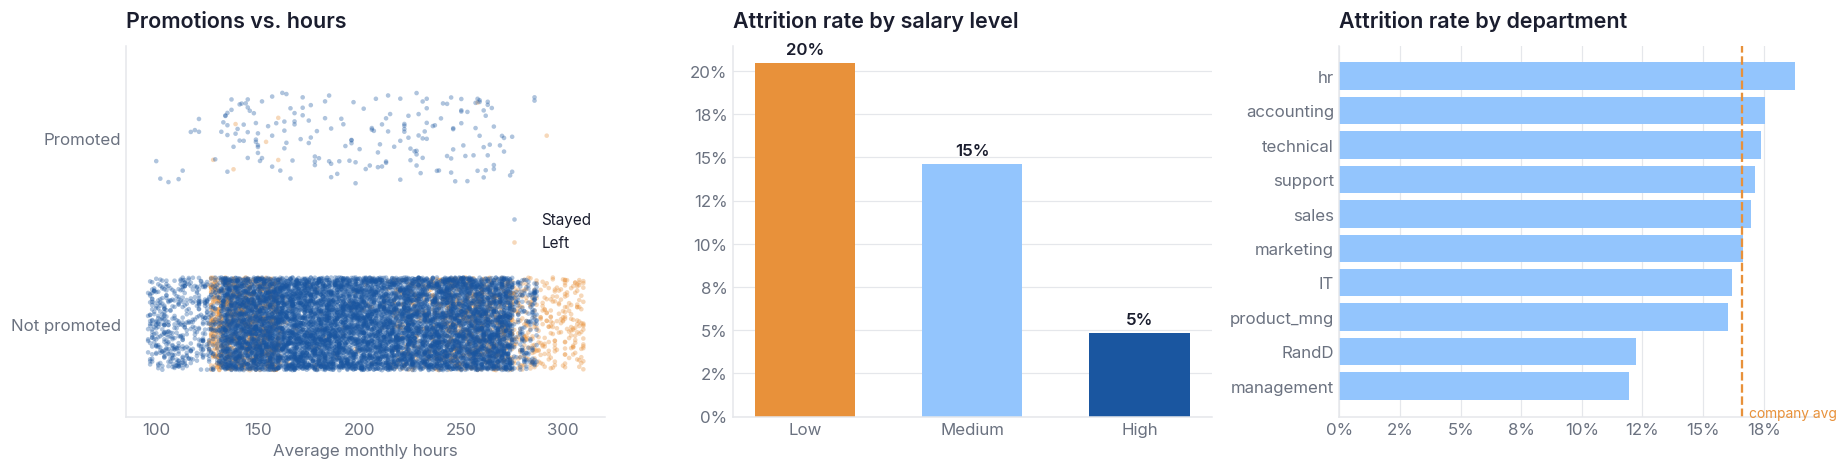

Promoted in the last 5 years: 1.7% of employees; among those working >250 h/month: 1.5%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17,4.4))
sns.stripplot(data=df, x='average_monthly_hours', y='promotion_last_5years', hue='left', orient='h', alpha=.35,
              palette=PAL, jitter=.25, size=3, ax=axes[0]); axes[0].invert_yaxis()
axes[0].set_yticks([0,1], ['Not promoted','Promoted']); axes[0].set_ylabel(''); axes[0].set_xlabel('Average monthly hours')
h,_ = axes[0].get_legend_handles_labels(); axes[0].legend(h, ['Stayed','Left'], loc='center right')
finish(axes[0], 'Promotions vs. hours')
sal = df.groupby('salary')['left'].mean().reindex(['low','medium','high'])
axes[1].bar(['Low','Medium','High'], sal.values, color=[ORANGE, SKY, BLUE], width=.6)
for i,v in enumerate(sal.values): axes[1].text(i, v+.005, f'{v:.0%}', ha='center', fontweight='semibold')
axes[1].yaxis.set_major_formatter(lambda v,_: f'{v:.0%}'); finish(axes[1], 'Attrition rate by salary level')
dep = df.groupby('department')['left'].mean().sort_values()
axes[2].barh(dep.index, dep.values, color=SKY); axes[2].axvline(df.left.mean(), c=ORANGE, ls='--', lw=1.5)
axes[2].text(df.left.mean()+.003, -.9, 'company avg', color=ORANGE, fontsize=9); axes[2].grid(axis='x'); axes[2].grid(axis='y', visible=False)
axes[2].xaxis.set_major_formatter(lambda v,_: f'{v:.0%}'); finish(axes[2], 'Attrition rate by department')
plt.tight_layout(); plt.savefig('../images/fig_promo_salary_dept.png'); plt.show()
print(f"Promoted in the last 5 years: {df.promotion_last_5years.mean():.1%} of employees; "
      f"among those working >250 h/month: {df[df.average_monthly_hours>250].promotion_last_5years.mean():.1%}")

* Only **~2%** of employees were promoted in the last five years — and even fewer among those working more than 250 hours a month. Nearly everyone who left was overworked and not promoted.
* Low salary: 20% attrition; high salary: 5%.
* **Department is not a driver:** the range is 12–19%. The problem is company-wide, not a "bad department."

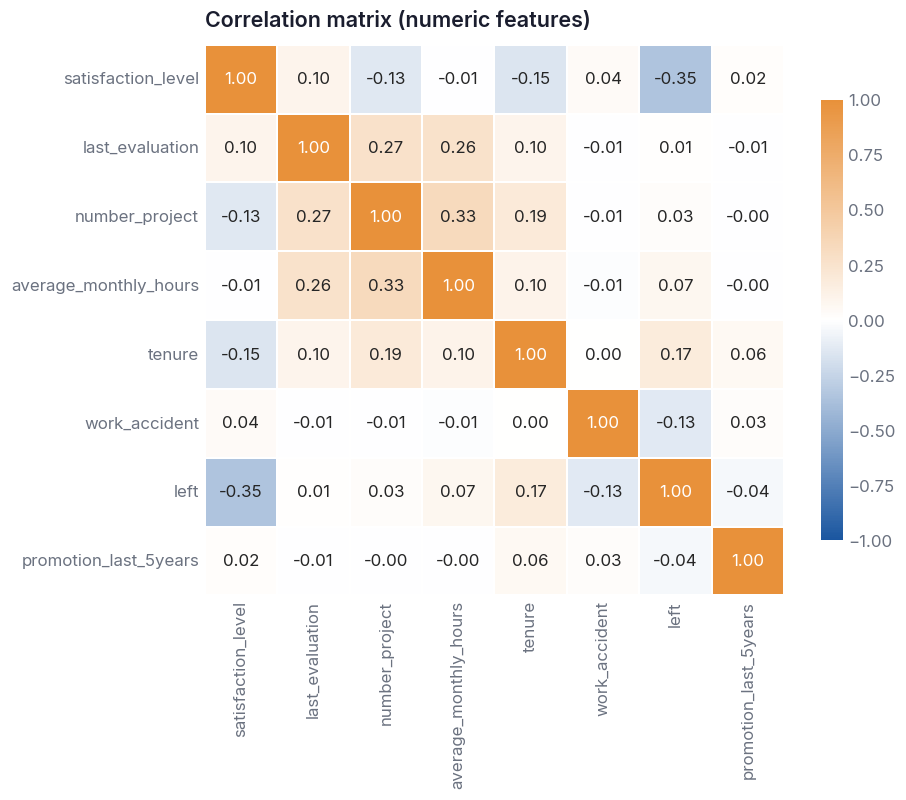

In [12]:
fig, ax = plt.subplots(figsize=(8.5,6.5))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap=BRAND_CMAP, center=0, vmin=-1, vmax=1,
            linewidths=1, linecolor='white', cbar_kws={'shrink':.8}, ax=ax)
ax.grid(False); finish(ax, 'Correlation matrix (numeric features)'); plt.show()

The strongest linear relationship with attrition is satisfaction (−0.35). Projects, hours, and evaluation are correlated with one another (0.33–0.42): high performers get more work. The relationships are non-linear (U-shaped), so we expect tree-based models to beat logistic regression.

### 2.1 Hypothesis testing
We check that the differences seen in EDA are not due to chance (significance level α = 0.05).
* **H₀:** salary level and attrition are independent · **H₁:** they are associated (chi-square test of independence).
* **H₀:** the distributions of hours / satisfaction are the same for employees who left and who stayed · **H₁:** they differ (Mann–Whitney U test — the distributions are not normal, so we use a non-parametric test instead of a t-test).

In [13]:
from scipy import stats
n = len(df)
for col in ['salary','department']:
    ct = pd.crosstab(df[col], df['left']); chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"Chi-square ({col} × left): χ²={chi2:.1f}, df={dof}, p={p:.2e}, Cramér's V={np.sqrt(chi2/(n*(min(ct.shape)-1))):.3f}")
for col in ['average_monthly_hours','satisfaction_level']:
    a, b = df.loc[df.left==1,col], df.loc[df.left==0,col]
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f'Mann–Whitney ({col}): median left={a.median():.2f}, stayed={b.median():.2f}, p={p:.2e}')

Chi-square (salary × left): χ²=175.2, df=2, p=8.98e-39, Cramér's V=0.121


Chi-square (department × left): χ²=20.9, df=9, p=1.33e-02, Cramér's V=0.042
Mann–Whitney (average_monthly_hours): median left=226.00, stayed=198.00, p=1.83e-07
Mann–Whitney (satisfaction_level): median left=0.41, stayed=0.69, p=2.24e-266


<div style="background:#eff6ff;border-left:3px solid #1a56a0;border-radius:0 8px 8px 0;padding:12px 16px;color:#1e3a6e;font-size:13px"><strong>Result:</strong> every H₀ is rejected, but <strong>effect size</strong> matters more than the p-value. Salary has a weak-to-moderate association with attrition (V ≈ 0.12). Department is formally significant (p ≈ 0.01), but the effect is negligible (V ≈ 0.04) — with a large sample, significance picks up even trivial differences. This confirms that department is not a management lever, unlike workload and satisfaction (median satisfaction 0.41 vs. 0.69).</div>

<div style="font-size:11px;font-weight:600;letter-spacing:.12em;text-transform:uppercase;color:#1a56a0">Stage 3 · Construct</div>

## Build the Models

**Strategy (two rounds):**
* **Round 1 — all features.** Maximum accuracy, but relies on `satisfaction_level` from the survey.
* **Round 2 — no survey data.** Drop `satisfaction_level`; add `overworked` (>175 hours/month) and `hours_per_project`. This model runs on HRIS data as-is, without regular surveys, and reduces leakage risk (satisfaction may have been recorded after the decision to leave was made). **This is the model we recommend deploying**, provided performance is comparable.

**Protocol:** stratified 25% hold-out (the test set is used exactly once, at the end) → 5-fold CV with hyperparameter tuning on the training set → selection by CV F1.

In [14]:
def prep(frame):
    X = frame.copy()
    X['salary'] = X['salary'].map({'low':0,'medium':1,'high':2})   # ordinal
    return pd.get_dummies(X, columns=['department'], drop_first=False, dtype=int)

df_enc = prep(df)
y = df_enc['left']; X = df_enc.drop(columns='left')
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25, stratify=y, random_state=RS)
cv = StratifiedKFold(5, shuffle=True, random_state=RS)
SCORING = {'accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1','roc_auc':'roc_auc'}
results = []

def cv_row(name, gs):
    r = pd.DataFrame(gs.cv_results_).iloc[gs.best_index_]
    row = {'model':name, **{m: r[f'mean_test_{m}'] for m in SCORING}}
    results.append(row); return row

def test_row(name, model, Xt, yt, thr=.5):
    p = model.predict_proba(Xt)[:,1]; yhat = (p>=thr).astype(int)
    return {'model':name,'accuracy':accuracy_score(yt,yhat),'precision':precision_score(yt,yhat),
            'recall':recall_score(yt,yhat),'f1':f1_score(yt,yhat),'roc_auc':roc_auc_score(yt,p)}
print(X_tr.shape, X_te.shape, f'attrition rate train/test: {y_tr.mean():.3f}/{y_te.mean():.3f}')

(8993, 18) (2998, 18) attrition rate train/test: 0.166/0.166


### 3.1 Logistic regression (interpretable baseline)
Assumptions: independent observations, no severe multicollinearity, no extreme outliers → we exclude tenure outliers from training and scale the features.

In [15]:
mask = X_tr['tenure'] <= upper
lr = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=RS)),
                  {'logisticregression__C':[0.01,0.1,1,10]}, scoring=SCORING, refit='f1', cv=cv, n_jobs=-1)
lr.fit(X_tr[mask], y_tr[mask]); cv_row('LogReg (R1)', lr)
coefs = pd.Series(lr.best_estimator_[-1].coef_[0], index=X_tr.columns)
odds = np.exp(coefs).sort_values()
print('Odds ratios (per 1 SD of each feature):'); print(odds[~odds.index.str.startswith('department')].round(2))

Odds ratios (per 1 SD of each feature):
satisfaction_level      0.340
number_project          0.570
work_accident           0.590
salary                  0.710
promotion_last_5years   0.910
last_evaluation         0.990
average_monthly_hours   1.190
tenure                  2.590
dtype: float64


Odds ratios (per 1 SD): satisfaction is the strongest protective factor (odds of leaving ×0.34); tenure is the strongest risk factor (×2.6); higher salary and a work accident lower the odds (plausibly because injured employees receive extra support and protections).

**Important caveat:** the `number_project` coefficient is < 1 ("more projects, less attrition"), which contradicts the EDA. This is a symptom of the U-shaped relationship: a linear model cannot describe attrition at both 2 and 7 projects, so it averages them out. Hence recall ≈ 0.25 — the model misses 3 of every 4 leavers. We keep logistic regression to illustrate the direction of effects, not as the production model.

### 3.2 Decision tree, random forest, XGBoost (Round 1)

In [16]:
dt = GridSearchCV(DecisionTreeClassifier(random_state=RS),
     {'max_depth':[4,6,8,None],'min_samples_leaf':[1,5]},
     scoring=SCORING, refit='f1', cv=cv, n_jobs=-1).fit(X_tr, y_tr); cv_row('Decision Tree (R1)', dt)
rf = GridSearchCV(RandomForestClassifier(random_state=RS, n_jobs=-1),
     {'n_estimators':[200],'max_depth':[None,10],'max_features':[.5],'min_samples_leaf':[1,2]},
     scoring=SCORING, refit='f1', cv=cv, n_jobs=-1).fit(X_tr, y_tr); cv_row('Random Forest (R1)', rf)
xgb = GridSearchCV(XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=RS, n_jobs=-1),
      {'max_depth':[4,6],'learning_rate':[.1],'n_estimators':[200],'subsample':[.8],'colsample_bytree':[.8]},
      scoring=SCORING, refit='f1', cv=cv, n_jobs=-1).fit(X_tr, y_tr); cv_row('XGBoost (R1)', xgb)
pd.DataFrame(results).set_index('model').round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogReg (R1),0.826,0.462,0.252,0.326,0.885
Decision Tree (R1),0.981,0.969,0.918,0.942,0.960
Random Forest (R1),0.984,0.988,0.915,0.950,0.980
XGBoost (R1),0.983,0.975,0.920,0.947,0.984


### 3.3 Round 2 — model without survey data

In [17]:
def add_fe(Xf):
    Xf = Xf.drop(columns='satisfaction_level').copy()
    Xf['overworked'] = (Xf['average_monthly_hours'] > 175).astype(int)
    Xf['hours_per_project'] = Xf['average_monthly_hours'] / Xf['number_project']
    return Xf
X2_tr, X2_te = add_fe(X_tr), add_fe(X_te)
dt2 = GridSearchCV(DecisionTreeClassifier(random_state=RS),
      {'max_depth':[4,6,8,None],'min_samples_leaf':[1,5]},
      scoring=SCORING, refit='f1', cv=cv, n_jobs=-1).fit(X2_tr, y_tr); cv_row('Decision Tree (R2)', dt2)
rf2 = GridSearchCV(RandomForestClassifier(random_state=RS, n_jobs=-1),
      {'n_estimators':[200],'max_depth':[None,10],'max_features':[.5],'min_samples_leaf':[1,2]},
      scoring=SCORING, refit='f1', cv=cv, n_jobs=-1).fit(X2_tr, y_tr); cv_row('Random Forest (R2)', rf2)
xgb2 = GridSearchCV(XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=RS, n_jobs=-1),
       {'max_depth':[4,6],'learning_rate':[.1],'n_estimators':[200],'subsample':[.8],'colsample_bytree':[.8]},
       scoring=SCORING, refit='f1', cv=cv, n_jobs=-1).fit(X2_tr, y_tr); cv_row('XGBoost (R2)', xgb2)
cv_table = pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False)
cv_table.to_csv('../reports/cv_results.csv')
cv_table.style.format('{:.3f}').background_gradient(cmap=LinearSegmentedColormap.from_list('b',['#ffffff',SKY,BLUE]), subset=['f1','recall','roc_auc'])

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest (R1),0.984,0.988,0.915,0.950,0.980
XGBoost (R1),0.983,0.975,0.920,0.947,0.984
Decision Tree (R1),0.981,0.969,0.918,0.942,0.960
Random Forest (R2),0.975,0.934,0.912,0.922,0.975
XGBoost (R2),0.973,0.932,0.904,0.918,0.980
Decision Tree (R2),0.969,0.908,0.904,0.905,0.956
LogReg (R1),0.826,0.462,0.252,0.326,0.885


<div style="background:#eff6ff;border-left:3px solid #1a56a0;border-radius:0 8px 8px 0;padding:12px 16px;color:#1e3a6e;font-size:13px"><strong>Champion selection.</strong> The best Round 1 model is nearly perfect but depends on the survey. The Round 2 model gives up only a few points of F1 while keeping AUC around 0.97 — and it doesn't need the survey. We check both on the hold-out set <strong>exactly once</strong>.</div>

In [18]:
best_r1 = max([('Decision Tree (R1)',dt),('Random Forest (R1)',rf),('XGBoost (R1)',xgb)], key=lambda t:t[1].best_score_)
best_r2 = max([('Decision Tree (R2)',dt2),('Random Forest (R2)',rf2),('XGBoost (R2)',xgb2)], key=lambda t:t[1].best_score_)
test_tbl = pd.DataFrame([test_row(best_r1[0], best_r1[1].best_estimator_, X_te, y_te),
                         test_row(best_r2[0], best_r2[1].best_estimator_, X2_te, y_te),
                         test_row('LogReg (R1)', lr.best_estimator_, X_te, y_te)]).set_index('model')
test_tbl.to_csv('../reports/test_results.csv')
print('Best R2 parameters:', best_r2[1].best_params_)
test_tbl.round(3)

Best R2 parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest (R1),0.986,0.991,0.926,0.957,0.978
Random Forest (R2),0.979,0.950,0.920,0.935,0.972
LogReg (R1),0.787,0.326,0.263,0.291,0.842


<div style="font-size:11px;font-weight:600;letter-spacing:.12em;text-transform:uppercase;color:#1a56a0">Stage 4 · Execute</div>

## Evaluate, Interpret, Apply

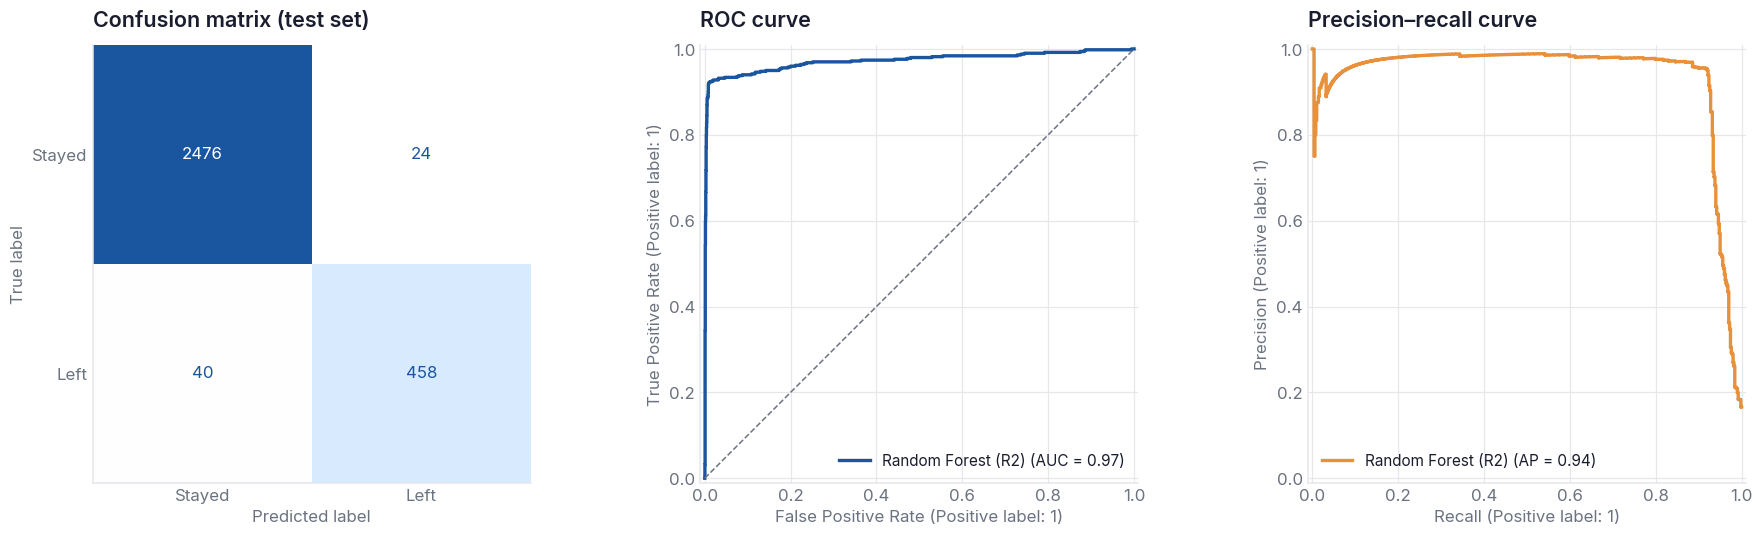

              precision    recall  f1-score   support

      Stayed      0.984     0.990     0.987      2500
        Left      0.950     0.920     0.935       498

    accuracy                          0.979      2998
   macro avg      0.967     0.955     0.961      2998
weighted avg      0.978     0.979     0.979      2998



In [19]:
champ_name, champ = best_r2[0], best_r2[1].best_estimator_
p_te = champ.predict_proba(X2_te)[:,1]
fig, axes = plt.subplots(1, 3, figsize=(17,5))
cm = confusion_matrix(y_te, (p_te>=.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=['Stayed','Left']).plot(ax=axes[0], values_format='d', colorbar=False,
     cmap=LinearSegmentedColormap.from_list('b',['#ffffff',SKY,BLUE]))
axes[0].grid(False); finish(axes[0], 'Confusion matrix (test set)')
RocCurveDisplay.from_predictions(y_te, p_te, ax=axes[1], name=champ_name, color=BLUE, lw=2.2)
axes[1].plot([0,1],[0,1], ls='--', c=MUTED, lw=1); axes[1].grid(axis='x'); finish(axes[1], 'ROC curve')
PrecisionRecallDisplay.from_predictions(y_te, p_te, ax=axes[2], name=champ_name, color=ORANGE, lw=2.2)
axes[2].grid(axis='x'); finish(axes[2], 'Precision–recall curve')
plt.tight_layout(); plt.savefig('../images/fig_eval.png'); plt.show()
print(classification_report(y_te, (p_te>=.5).astype(int), target_names=['Stayed','Left'], digits=3))

### 4.1 Decision threshold — business tuning
0.5 is not sacred. If missing a departing employee costs much more than an unnecessary conversation, the threshold should come down. We choose the threshold on **cross-validated (out-of-fold) predictions from the training set**, not on the test set, to avoid overfitting.

In [20]:
oof = cross_val_predict(champ, X2_tr, y_tr, cv=cv, method='predict_proba')[:,1]
rows=[]
for thr in [.2,.3,.4,.5,.6]:
    yh=(oof>=thr).astype(int)
    rows.append({'threshold':thr,'precision':precision_score(y_tr,yh),'recall':recall_score(y_tr,yh),'f1':f1_score(y_tr,yh),
                 'flags_per_100_employees':yh.mean()*100})
thr_tbl = pd.DataFrame(rows).set_index('threshold'); thr_tbl.round(3)

,precision,recall,f1,flags_per_100_employees
threshold,,,,
0.200,0.858,0.927,0.891,17.936
0.300,0.899,0.920,0.909,16.991
0.400,0.921,0.918,0.920,16.546
0.500,0.933,0.912,0.922,16.213
0.600,0.945,0.904,0.924,15.879


<div style="background:#eff6ff;border-left:3px solid #1a56a0;border-radius:0 8px 8px 0;padding:12px 16px;color:#1e3a6e;font-size:13px"><strong>Takeaway:</strong> F1 barely moves across thresholds (0.89–0.92) — the model separates the classes well and is confident. For the pilot, we recommend a <strong>0.4</strong> threshold: precision ≈ recall ≈ 0.92, meaning ~92 of every 100 flags are true risks and we catch ~92% of future departures. If HR capacity is limited, use 0.6 (fewer false alarms).</div>

### 4.2 What drives attrition

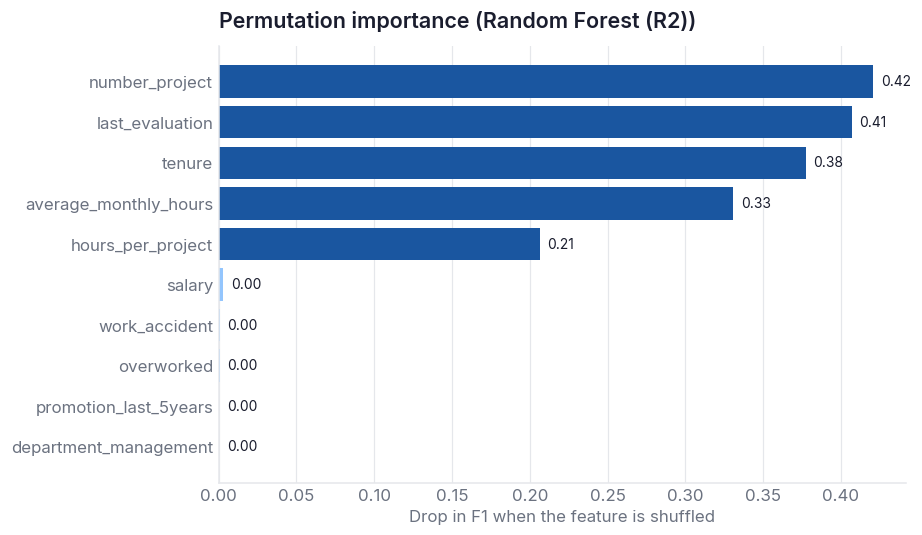

number_project          0.421
last_evaluation         0.407
tenure                  0.377
average_monthly_hours   0.331
hours_per_project       0.206
salary                  0.003
work_accident           0.001
overworked              0.001
promotion_last_5years   0.000
department_management   0.000
dtype: float64

In [21]:
pi = permutation_importance(champ, X2_te, y_te, scoring='f1', n_repeats=5, random_state=RS, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X2_te.columns).sort_values(ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(8.5,5))
ax.barh(imp.index, imp.values, color=[BLUE if v>.1 else SKY for v in imp.values])
for yv, v in enumerate(imp.values): ax.text(v+.005, yv, f'{v:.2f}', va='center', fontsize=9)
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.set_xlabel('Drop in F1 when the feature is shuffled')
finish(ax, f'Permutation importance ({champ_name})')
plt.tight_layout(); plt.savefig('../images/fig_importance.png'); plt.show()
imp.sort_values(ascending=False).round(3)

<div style="background:#eff6ff;border-left:3px solid #1a56a0;border-radius:0 8px 8px 0;padding:12px 16px;color:#1e3a6e;font-size:13px"><strong>Takeaway:</strong> the decisive features are number of projects, last evaluation, tenure, and hours (plus the engineered <code>hours_per_project</code>). The low permutation importance of salary and promotions <strong>does not mean</strong> they don't matter to people: only 1.7% were promoted (the feature is nearly constant), and salary is correlated with other features. Decisions should rest on EDA, statistics, and the model together.</div>

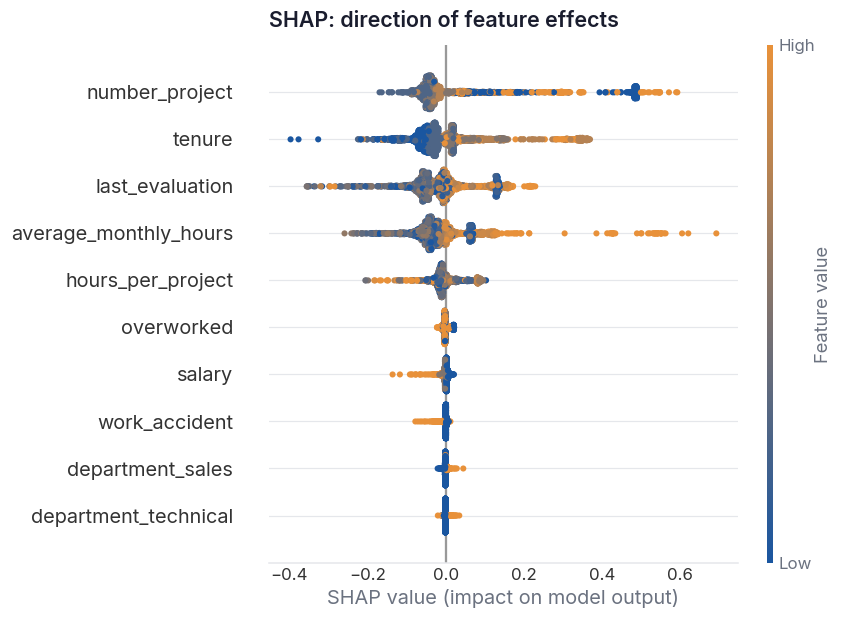

In [22]:
import shap
explainer = shap.TreeExplainer(champ)
sv = explainer.shap_values(X2_te)
sv = sv[1] if isinstance(sv, list) else (sv[..., 1] if np.ndim(sv)==3 else sv)
shap.summary_plot(sv, X2_te, max_display=10, show=False, cmap=LinearSegmentedColormap.from_list('s',[BLUE, ORANGE]))
plt.title('SHAP: direction of feature effects', loc='left', fontweight='semibold')
plt.savefig('../images/fig_shap.png'); plt.show()

**Reading SHAP:** orange dots on the right = high feature values push risk up. High evaluation + many projects + overtime + 4–5 years of tenure increase risk; a very low project count does too (the U-shape). The model learned exactly the profiles we found in EDA — an important sanity check.

Surrogate tree (3 levels): test F1 = 0.887


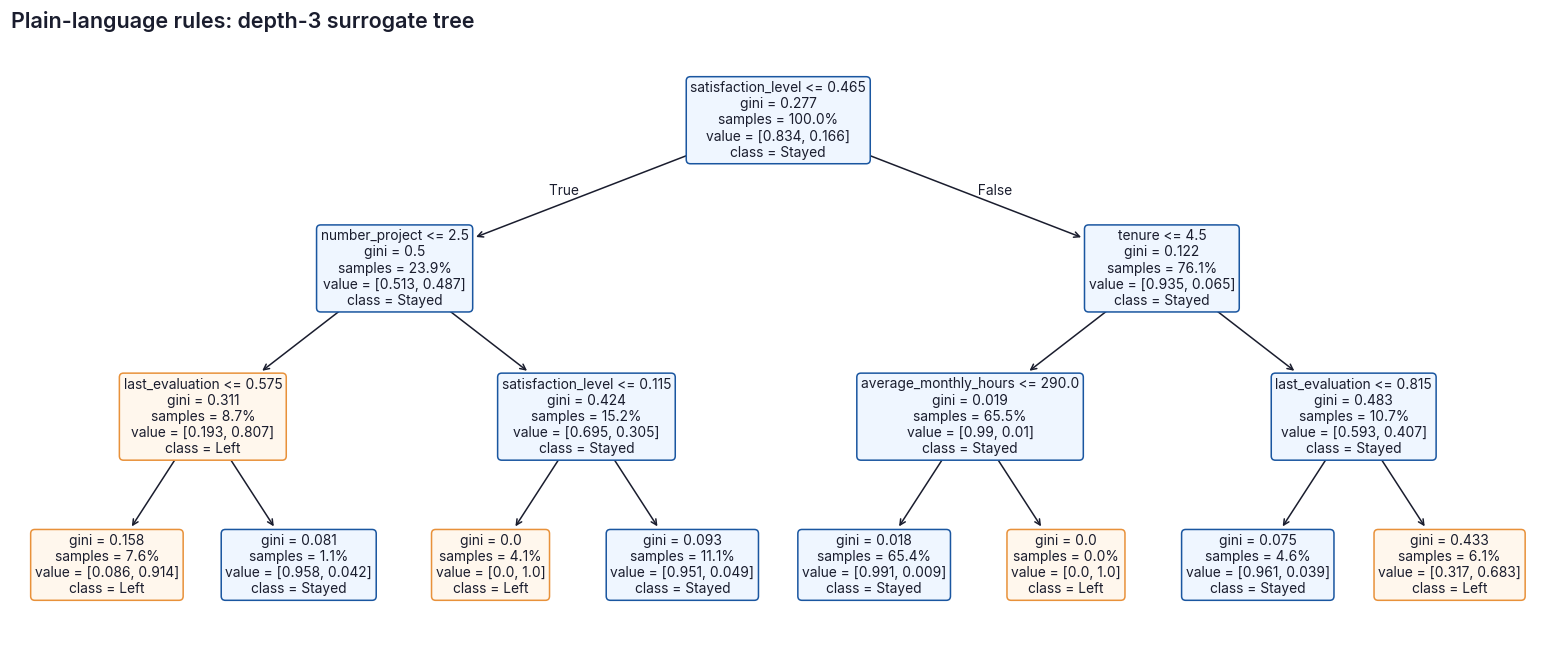

In [23]:
# Depth-3 surrogate tree — simple rules for HR (explainability for a non-technical audience)
sur = DecisionTreeClassifier(max_depth=3, random_state=RS).fit(X_tr, y_tr)
print(f'Surrogate tree (3 levels): test F1 = {f1_score(y_te, sur.predict(X_te)):.3f}')
fig, ax = plt.subplots(figsize=(18,7))
art = plot_tree(sur, feature_names=list(X_tr.columns), class_names=['Stayed','Left'], filled=False, rounded=True,
                fontsize=9, proportion=True, ax=ax)
for a in art:
    txt = a.get_text()
    if a.get_bbox_patch() is not None:
        a.get_bbox_patch().set(fc='#fff7ed' if 'class = Left' in txt else '#eff6ff', ec=ORANGE if 'class = Left' in txt else BLUE)
ax.set_title('Plain-language rules: depth-3 surrogate tree', loc='left', fontweight='semibold')
plt.savefig('../images/fig_rules.png', dpi=130); plt.show()

### 4.3 Who is at risk right now

In [24]:
# Out-of-fold scores for current employees, so the model never "sees" a person during training
X2_all = add_fe(X)
oof_all = cross_val_predict(champ, X2_all, y, cv=cv, method='predict_proba')[:,1]
cur = df.assign(risk=oof_all)[df.left==0].copy()
cur['risk_band'] = pd.cut(cur.risk, [-.01,.3,.6,1.01], labels=['low','medium','high'])
print(cur['risk_band'].value_counts())
cur[cur.risk_band!='low'].groupby('department')['risk'].size().sort_values(ascending=False).rename('employees_at_risk')

risk_band
low       9819
high       103
medium      78
Name: count, dtype: int64


department
sales          41
technical      32
support        26
RandD          15
product_mng    15
accounting     15
marketing      14
IT             12
hr              7
management      4
Name: employees_at_risk, dtype: int64

In [25]:
hi = cur[cur.risk_band!='low']
hi[['number_project','average_monthly_hours','tenure','last_evaluation','satisfaction_level']].describe().loc[['mean','50%']].round(2)

,number_project,average_monthly_hours,tenure,last_evaluation,satisfaction_level
mean,4.430,237.030,4.710,0.830,0.480
50%,5.000,250.000,5.000,0.870,0.480


<div style="background:#fff7ed;border-left:3px solid #e8913a;border-radius:0 8px 8px 0;padding:12px 16px;color:#7c2d12;font-size:13px"><strong>Takeaway:</strong> of the 10,000 current employees, the model flags <strong>~180 (≈1.8%)</strong> as medium or high risk. Their typical profile — 5 projects, ~250 hours/month, 5 years of tenure, evaluation 0.87 — is the <strong>overworked high performer</strong>, exactly the group that is most costly to lose. Most are in sales, technical, and support (proportional to department size). The list is a starting point for manager conversations, not for penalties.</div>

<div style="font-size:11px;font-weight:600;letter-spacing:.12em;text-transform:uppercase;color:#1a56a0">Conclusion</div>

## Findings and Recommendations

**Model.** The recommended production model is **Random Forest without survey data (Round 2)**. On the hold-out test set: precision 0.95, recall 0.92, F1 0.935, AUC 0.97, accuracy 0.98 — it catches 92% of departing employees, and 95% of its flags are correct. The survey-based model is slightly more accurate (F1 0.957) but depends on regular surveys. Logistic regression (F1 0.29) is unsuitable because of the non-linear relationships.

**Key drivers:** workload (number of projects and hours), tenure of 4–5 years, performance (high evaluation combined with overwork), lack of promotions, and low pay. Department is not a driver.

**Recommendations for leadership:**
1. **Cap workload:** no more than 4–5 projects per person; treat >200 hours/month as a red flag. 7 projects = 100% attrition — a hard cap is essential.
2. **Pay for overtime or grant comp time**, or bring hours back to standard.
3. **Career track in years 3–5:** a promotion/compensation review for employees with 4+ years and high evaluations. Today only ~2% are promoted.
4. **Transparent evaluation criteria:** a high rating should not require 250+ hours; reward results, not hours.
5. **For the underloaded (2 projects):** find the cause — onboarding, work redistribution, or a managed exit.
6. **Operationalize:** monthly scoring of current employees; "high risk" → a conversation with the manager/HRBP, never a penalty.

**Limitations and next steps:**
* Voluntary and involuntary departures are not separated — they are different problems; the reason for leaving should be captured.
* The data is a single snapshot; the model needs validation on new data (drift) and quarterly retraining.
* Causality is not proven: the model shows associations. The impact of interventions should be tested with a pilot (A/B across departments).
* Useful additional features: date of last raise, manager change, time off, remote work status.